# Lab 11 - operacje morfologiczne

# Import bibliotek i definicje funkcji z poprzednich laboratoriów

In [40]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Definicje funkcji operacji morfologicznych 

In [41]:
def erozja(img, se):
    h, w = img.shape
    seh, sew = se.shape
    pad_h, pad_w = seh // 2, sew // 2
    padded = np.pad(
        img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant", constant_values=255
    )

    out = np.full_like(img, 255, dtype=np.uint8)
    for i in range(seh):
        for j in range(sew):
            if se[i, j]:
                out = np.minimum(out, padded[i : i + h, j : j + w])
    return out


def dylatacja(img, se):
    h, w = img.shape
    seh, sew = se.shape
    pad_h, pad_w = seh // 2, sew // 2
    padded = np.pad(
        img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant", constant_values=0
    )

    out = np.zeros_like(img, dtype=np.uint8)
    for i in range(seh):
        for j in range(sew):
            if se[i, j]:
                out = np.maximum(out, padded[i : i + h, j : j + w])
    return out


def otwarcie(img, se):
    # Otwarcie = Erozja, a następnie Dylatacja
    eroded = erozja(img, se)
    return dylatacja(eroded, se)


def zamkniecie(img, se):
    # Domknięcie = Dylatacja, a następnie Erozja
    dilated = dylatacja(img, se)
    return erozja(dilated, se)


def tophat(img, se):
    # Top-hat = Obraz - Otwarcie
    opened = otwarcie(img, se)
    result = img.astype(np.int16) - opened.astype(np.int16)
    # Wymuszamy poprawny zakres wartości pixeli
    return np.clip(result, 0, 255).astype(np.uint8)


def bottomhat(img, se):
    # Bottom-hat / Black-hat = Domknięcie - Obraz
    closed = zamkniecie(img, se)
    result = closed.astype(np.int16) - img.astype(np.int16)
    # Wymuszamy poprawny zakres wartości pixeli
    return np.clip(result, 0, 255).astype(np.uint8)


def hit_or_miss(img, base_kernel):
    img_bin = img > 127
    h, w = img.shape
    seh, sew = base_kernel.shape
    pad_h, pad_w = seh // 2, sew // 2
    padded = np.pad(
        img_bin, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant", constant_values=0
    )

    out = np.ones_like(img_bin, dtype=bool)
    for i in range(seh):
        for j in range(sew):
            # "1" = piksel obrazka musi być pierwszoplanowy (True)
            # "-1" = piksel obrazka musi być tłem (False)
            # "0" = dopasowanie nie ma znaczenia
            if base_kernel[i, j] == 1:
                out = out & (padded[i : i + h, j : j + w] == True)
            elif base_kernel[i, j] == -1:
                out = out & (padded[i : i + h, j : j + w] == False)

    return (out * 255).astype(np.uint8)

# Zadanie 1 - Erozja i dylatacja obrazów z użyciem różnych elementów strukturalnych

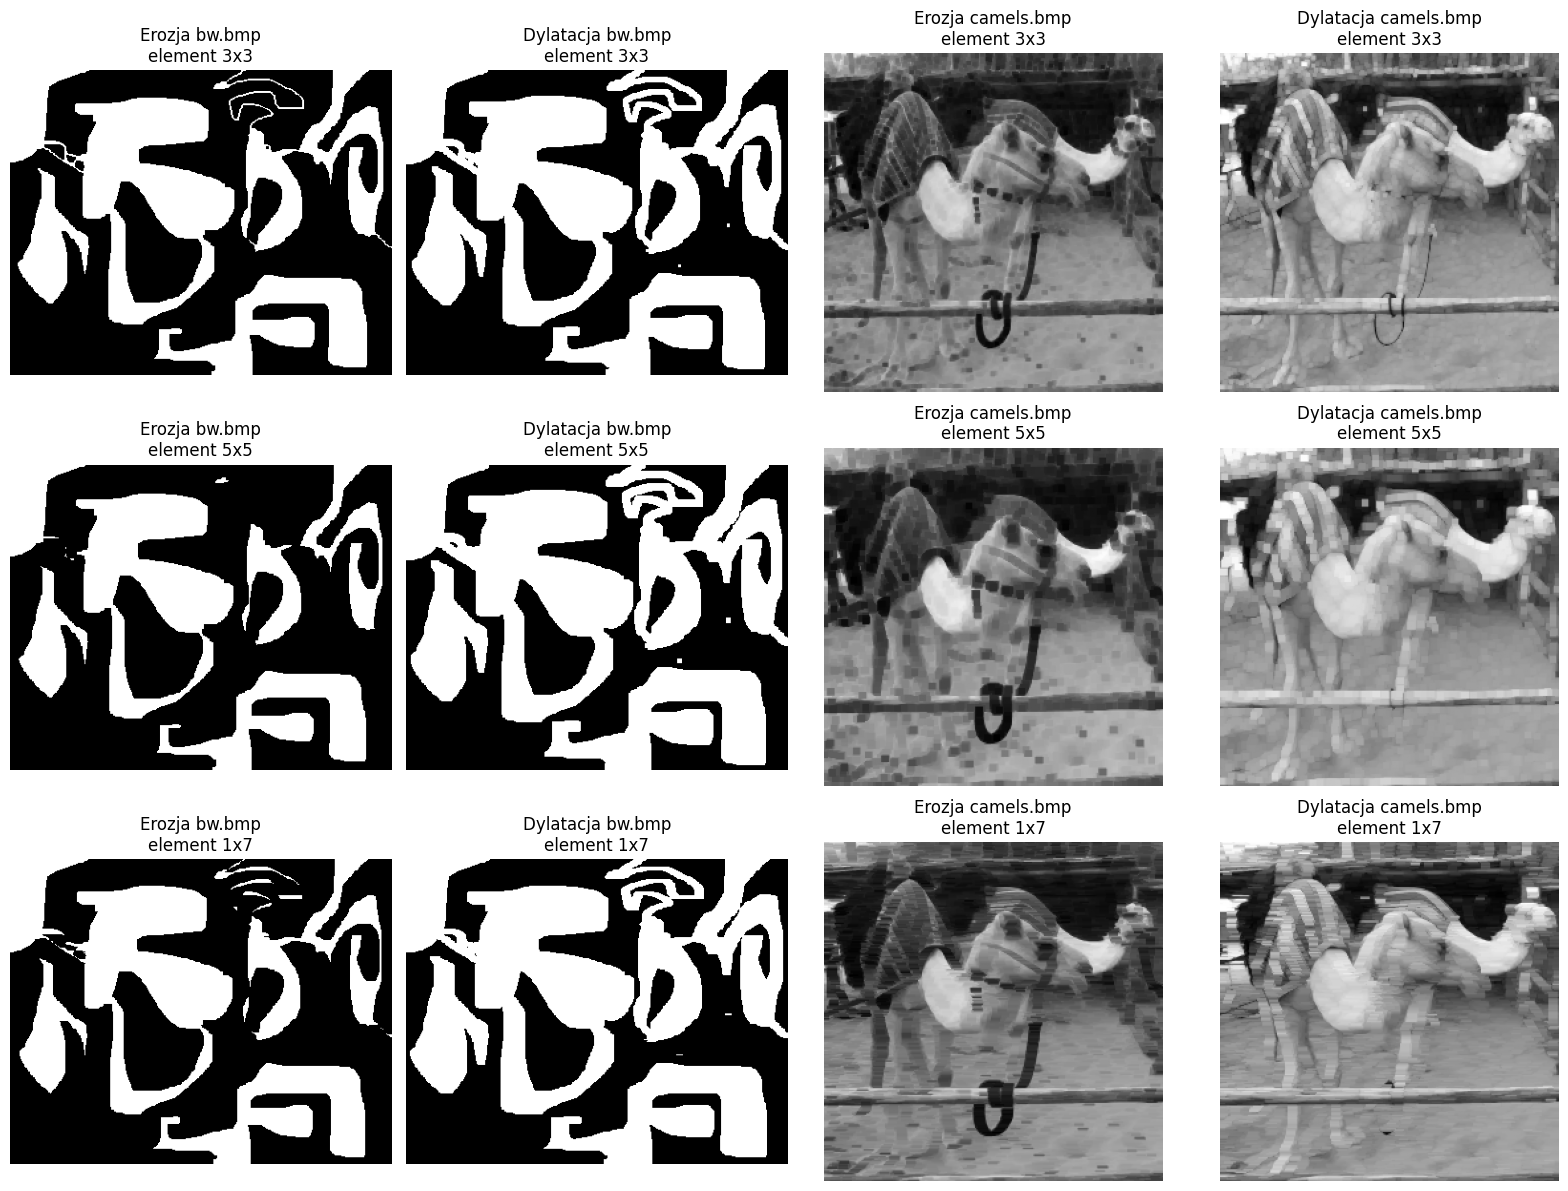

In [42]:
bw = cv2.imread("bw.bmp", cv2.IMREAD_GRAYSCALE)
camels = cv2.imread("camels.bmp", cv2.IMREAD_GRAYSCALE)

# elementy strukturalne
se1 = np.ones((3, 3), np.uint8)
se2 = np.ones((5, 5), np.uint8)
se3 = np.ones((1, 7), np.uint8)

# Erozja i dylatacja
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, (img, name) in enumerate([(bw, "bw.bmp"), (camels, "camels.bmp")]):
    for j, (se, se_name) in enumerate(
        [(se1, "element 3x3"), (se2, "element 5x5"), (se3, "element 1x7")]
    ):
        erode = erozja(img, se)
        dilate = dylatacja(img, se)

        axes[j, i * 2].imshow(erode, cmap="gray")
        axes[j, i * 2].set_title(f"Erozja {name}\n{se_name}")
        axes[j, i * 2].axis("off")

        axes[j, i * 2 + 1].imshow(dilate, cmap="gray")
        axes[j, i * 2 + 1].set_title(f"Dylatacja {name}\n{se_name}")
        axes[j, i * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

# Zadanie 2 - Otwarcie i domknięcie obrazów

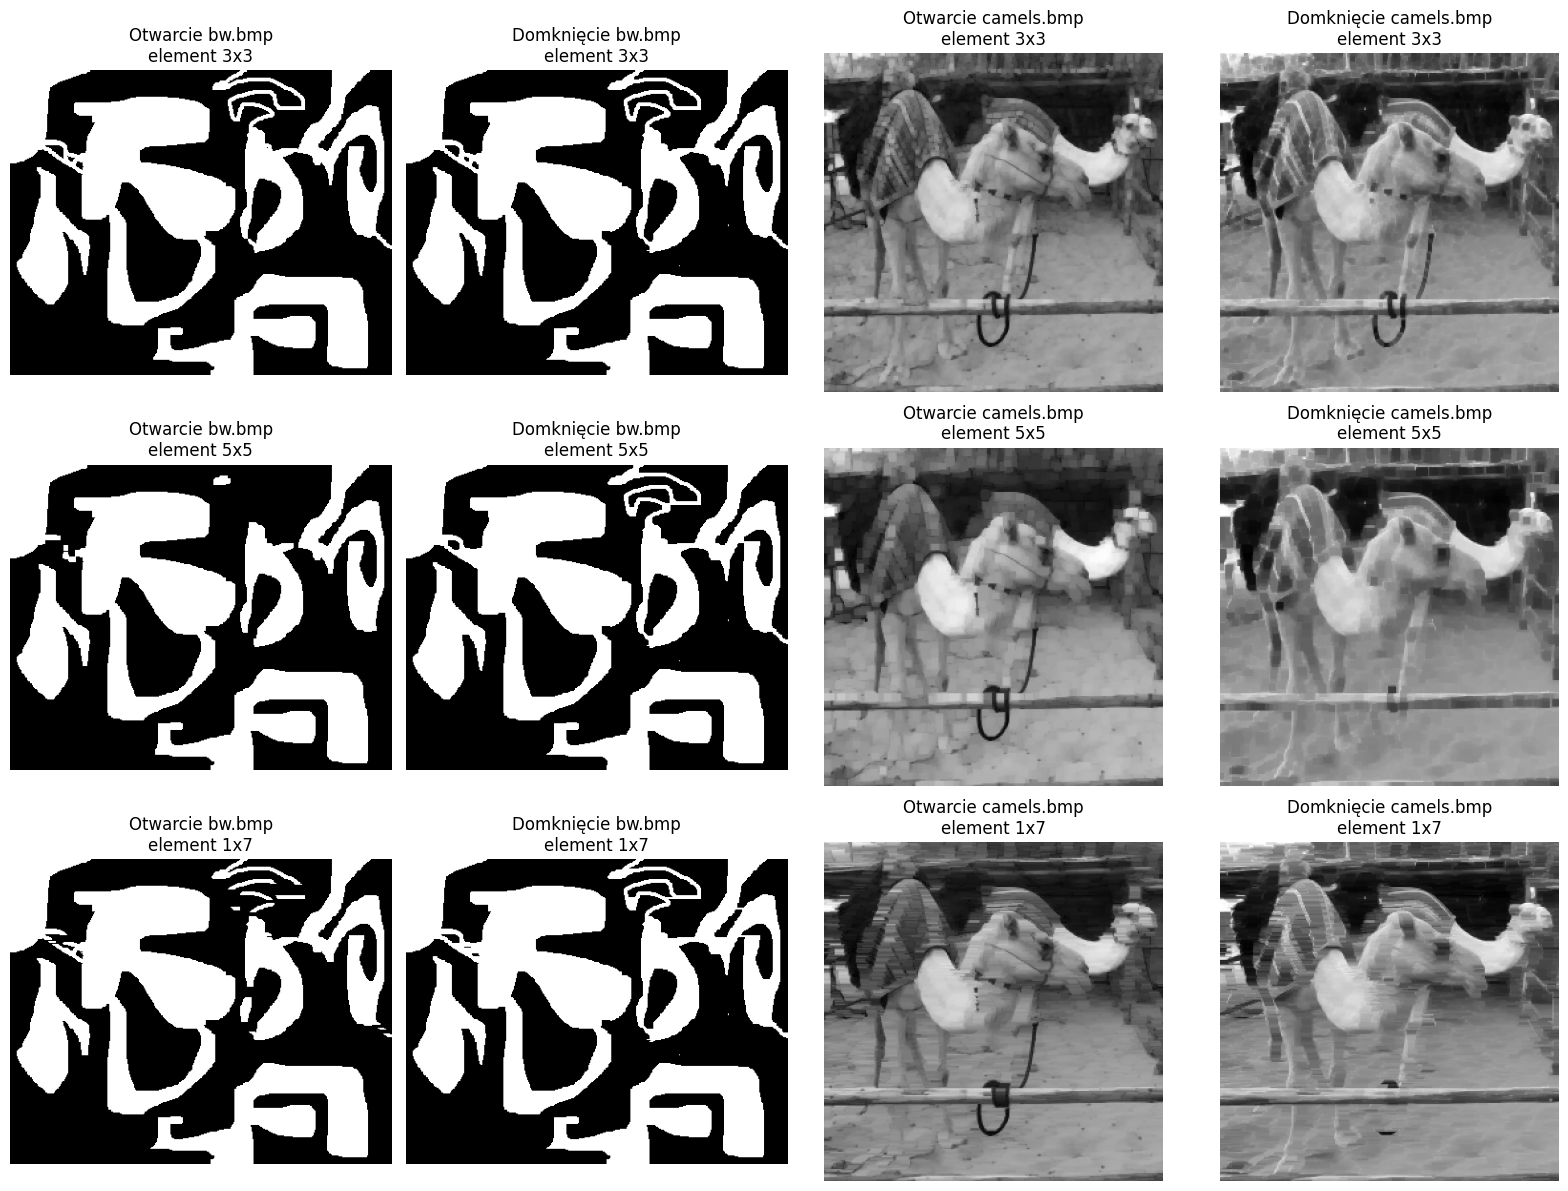

In [43]:
# Otwarcie = erozja z następcza dylatacja
# Domknięcie = dylatacja z następczą erozją

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, (img, name) in enumerate([(bw, "bw.bmp"), (camels, "camels.bmp")]):
    for j, (se, se_name) in enumerate(
        [(se1, "element 3x3"), (se2, "element 5x5"), (se3, "element 1x7")]
    ):
        opened = otwarcie(img, se)
        closed = zamkniecie(img, se)

        axes[j, i * 2].imshow(opened, cmap="gray")
        axes[j, i * 2].set_title(f"Otwarcie {name}\n{se_name}")
        axes[j, i * 2].axis("off")

        axes[j, i * 2 + 1].imshow(closed, cmap="gray")
        axes[j, i * 2 + 1].set_title(f"Domknięcie {name}\n{se_name}")
        axes[j, i * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

# Zadanie 3 - Operacje top-hat oraz bottom-hat

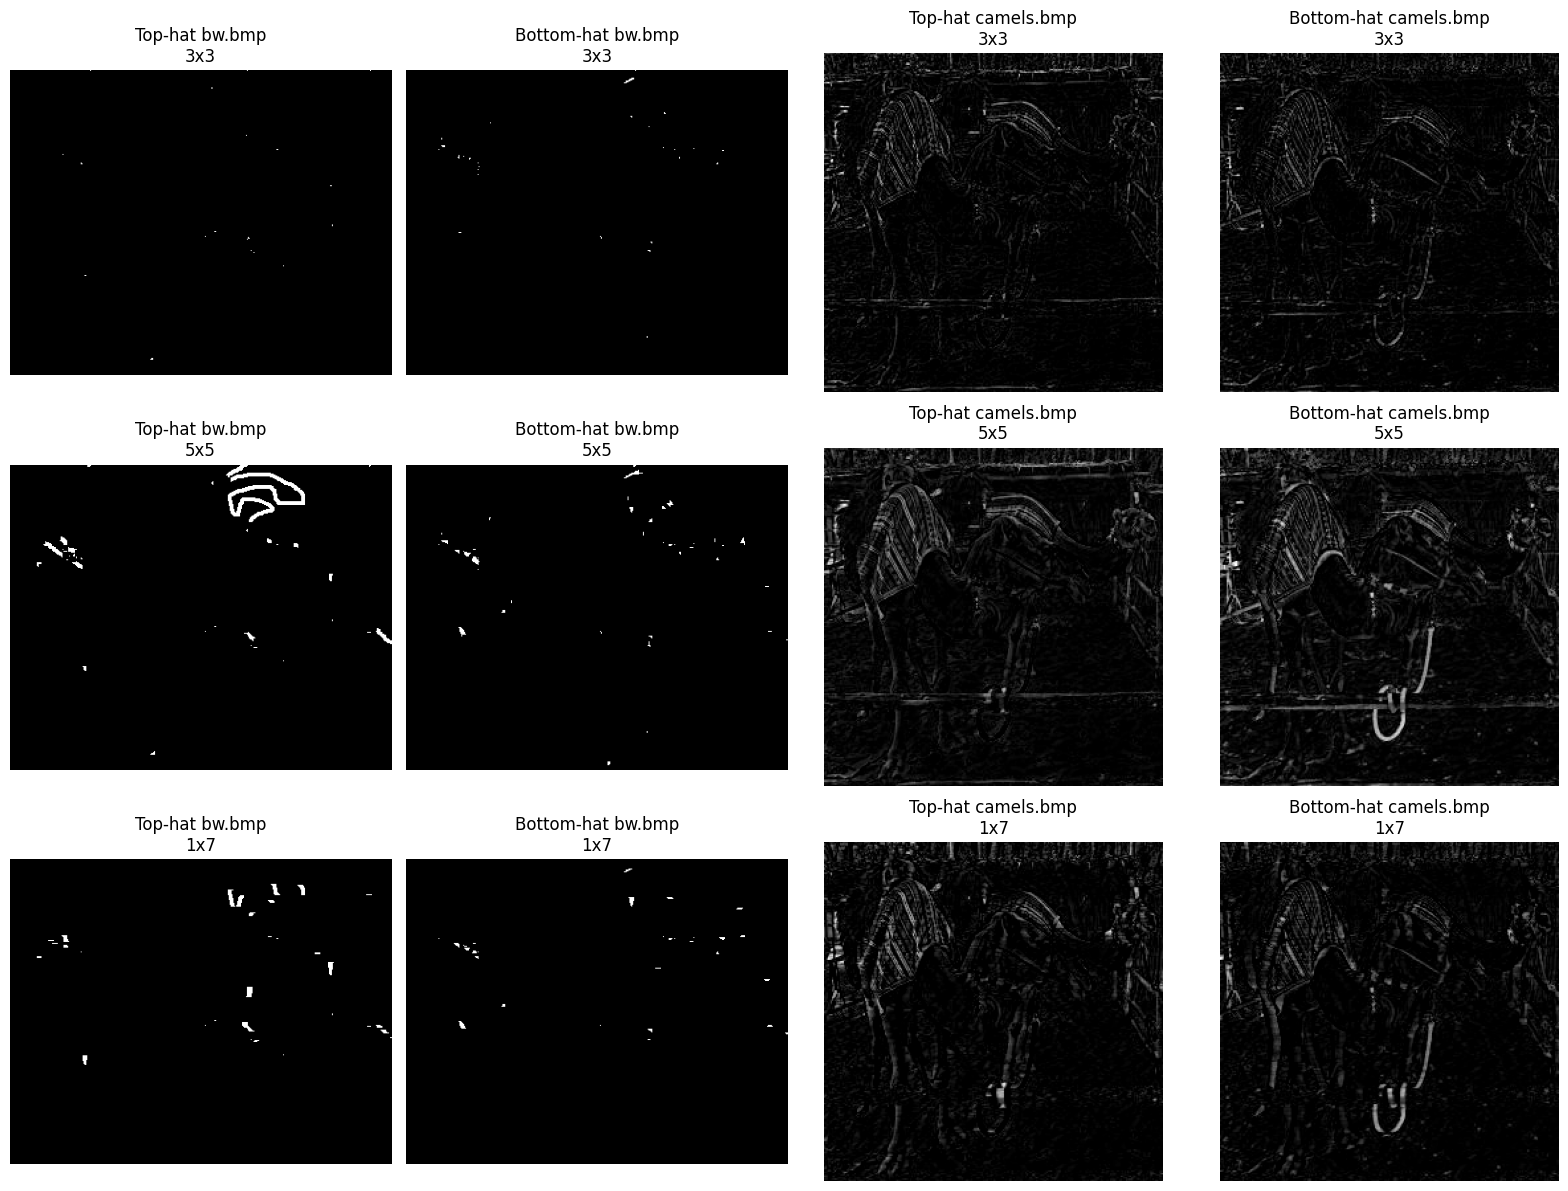

In [44]:
# Top-hat = img - otwarcie(img)
# Bottom-hat / Black-hat = domkniecie(img) - img

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, (img, name) in enumerate([(bw, "bw.bmp"), (camels, "camels.bmp")]):
    for j, (se, se_name) in enumerate([(se1, "3x3"), (se2, "5x5"), (se3, "1x7")]):
        that = tophat(img, se)
        bhat = bottomhat(img, se)

        axes[j, i * 2].imshow(that, cmap="gray")
        axes[j, i * 2].set_title(f"Top-hat {name}\n{se_name}")
        axes[j, i * 2].axis("off")

        axes[j, i * 2 + 1].imshow(bhat, cmap="gray")
        axes[j, i * 2 + 1].set_title(f"Bottom-hat {name}\n{se_name}")
        axes[j, i * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

# Zadanie 4 - Ścienianie obrazów binarnych i wyznaczanie szkieletu

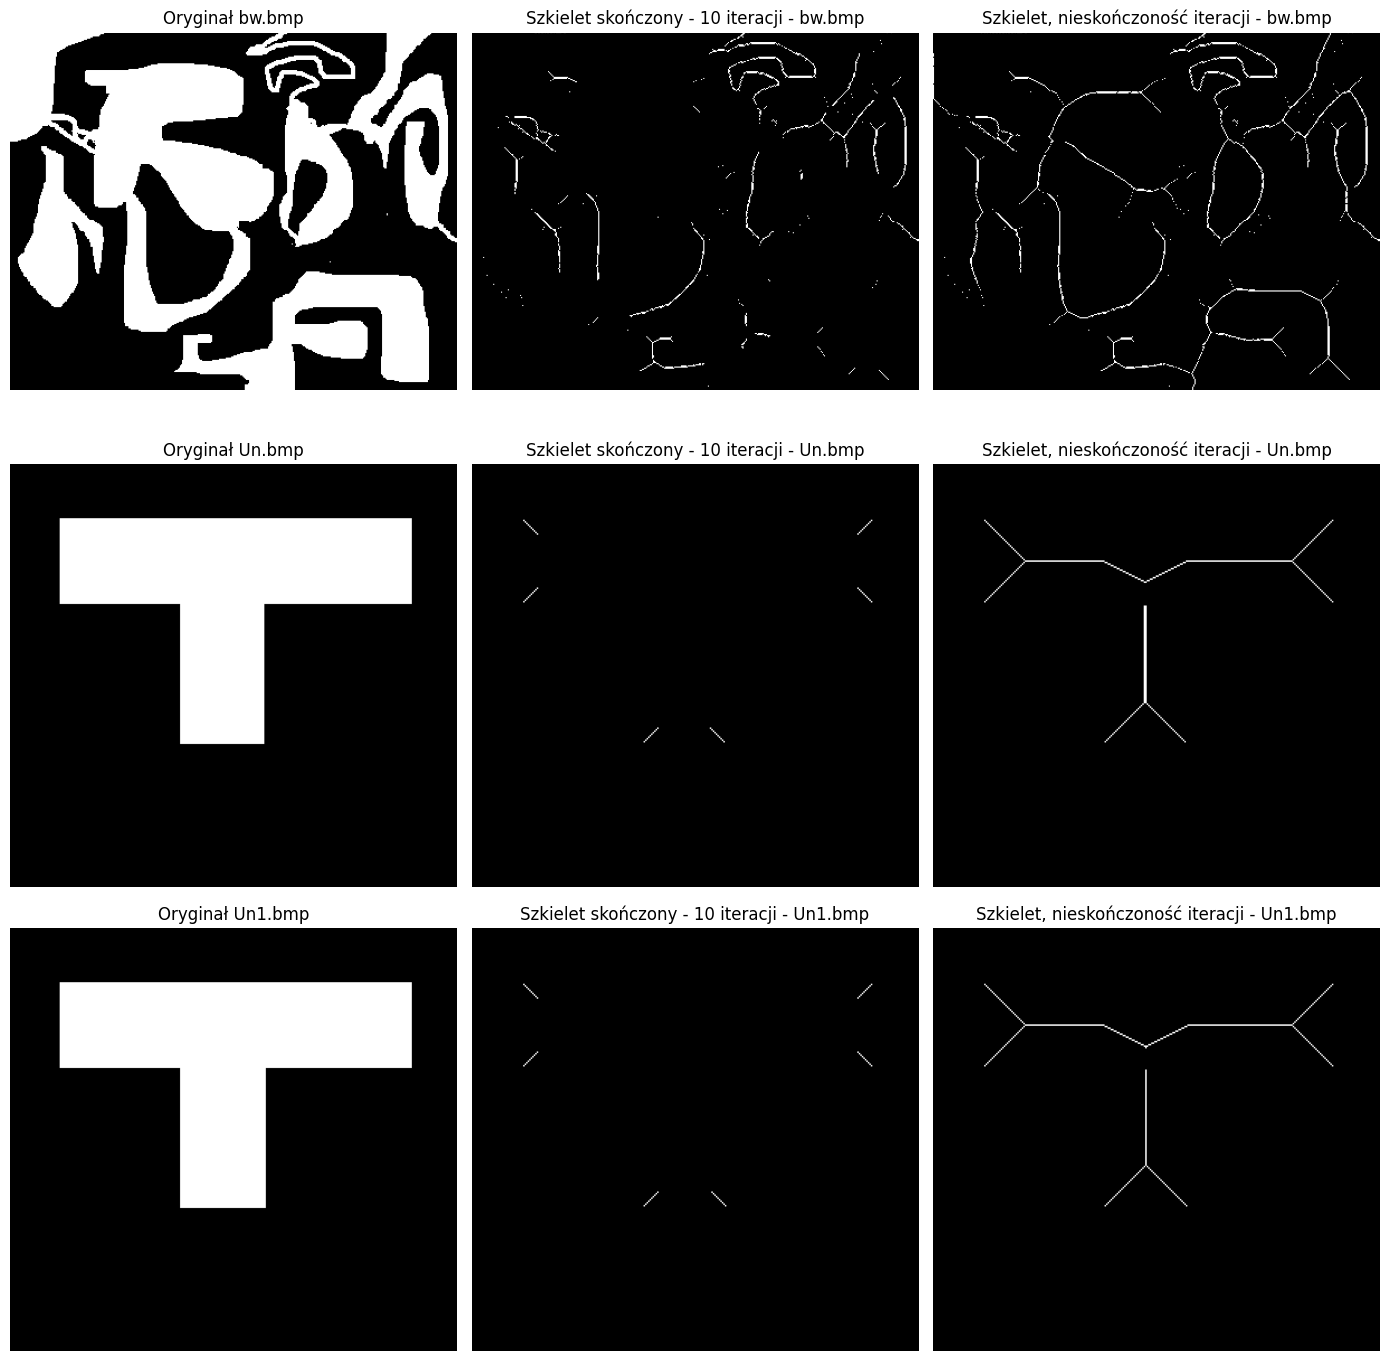

In [45]:
un = cv2.imread("Un.bmp", cv2.IMREAD_GRAYSCALE)
un1 = cv2.imread("Un1.bmp", cv2.IMREAD_GRAYSCALE)


def szkielet(img, max_iter=None):
    size = np.size(img)
    skel = np.zeros(img.shape, np.uint8)

    img_bin = np.where(img > 127, 255, 0).astype(np.uint8)

    # Element strukturalny (krzyż 3x3)
    element = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.uint8)

    iters = 0
    img_work = img_bin.copy()

    while True:
        eroded = erozja(img_work, element)
        opened = otwarcie(eroded, element)

        temp = np.clip(
            eroded.astype(np.int16) - opened.astype(np.int16), 0, 255
        ).astype(np.uint8)

        # Sumowanie części szkieletu
        skel = np.maximum(skel, temp)
        img_work = eroded.copy()

        iters += 1
        if max_iter is not None and iters >= max_iter:
            break

        # Zakończenie jeśli cały obraz to tło
        zeros = size - np.count_nonzero(img_work)
        if zeros == size:
            break

    return skel


fig, axes = plt.subplots(3, 3, figsize=(14, 14))
images = [(bw, "bw.bmp"), (un, "Un.bmp"), (un1, "Un1.bmp")]

for i, (img, name) in enumerate(images):
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Oryginał {name}")
    axes[i, 0].axis("off")

    sk_10 = szkielet(img, max_iter=10)  # n skoczone
    axes[i, 1].imshow(sk_10, cmap="gray")
    axes[i, 1].set_title(f"Szkielet skończony - 10 iteracji - {name}")
    axes[i, 1].axis("off")

    sk_inf = szkielet(img, max_iter=None)  # n nieskończone
    axes[i, 2].imshow(sk_inf, cmap="gray")
    axes[i, 2].set_title(f"Szkielet, nieskończoność iteracji - {name}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

# Zadanie 5 - Zrealizowanie własnej funkcji wyznaczania szkieletu opartą na transformacji hit-or-miss

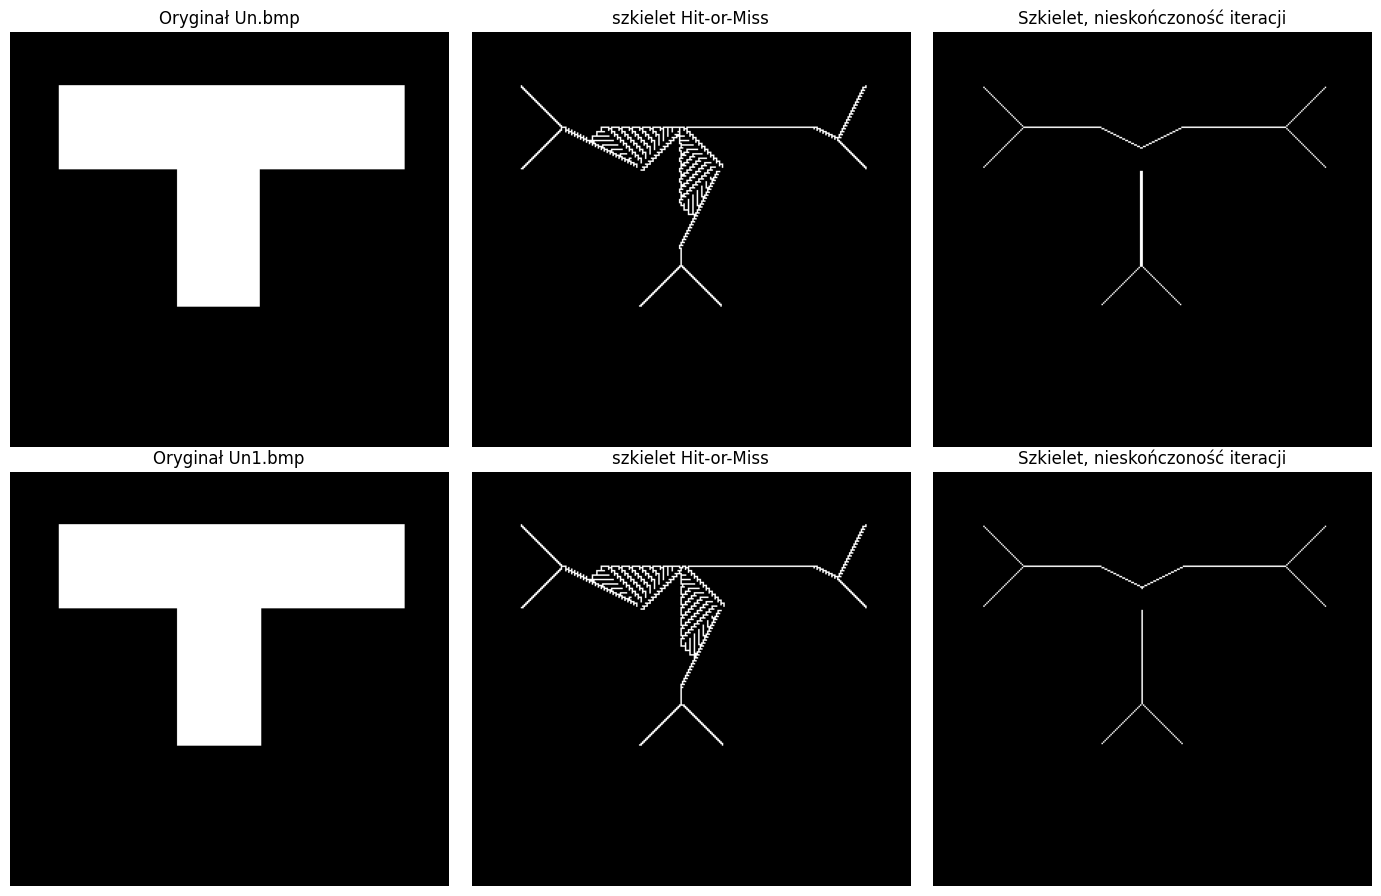

In [46]:
def get_hit_or_miss_elements():
    base = []

    # 0 = tło, 1 = obiekt
    base.append([[-1, -1, -1], [-1, 1, -1], [1, 1, 1]])
    base.append([[-1, -1, -1], [-1, 1, 1], [-1, 1, 1]])
    base.append([[-1, -1, -1], [1, 1, -1], [1, 1, -1]])
    base.append([[1, -1, -1], [1, 1, -1], [1, 1, 1]])
    base.append([[-1, -1, 1], [-1, 1, 1], [1, 1, 1]])
    base.append([[1, -1, 0], [1, 1, -1], [1, 1, -1]])

    base = []
    base.append([[-1, -1, -1], [1, 1, 1], [1, 1, 1]])
    base.append([[-1, -1, -1], [-1, 1, 1], [1, 1, 1]])
    base.append([[-1, -1, -1], [1, 1, -1], [1, 1, 1]])
    base.append([[1, -1, -1], [1, 1, -1], [1, 1, 1]])
    base.append([[-1, -1, 1], [-1, 1, 1], [1, 1, 1]])
    base.append([[1, -1, -1], [1, 1, 1], [1, 1, 1]])

    kernels = []
    for b in base:
        b_arr = np.array(b, dtype=np.int32)
        for i in range(4):  # Obrót o 0, 90, 180, 270 stopni
            rot = np.rot90(b_arr, k=i)
            if not any(np.array_equal(rot, k) for k in kernels):
                kernels.append(rot)

    return kernels


def szkielet_hit_or_miss(img):
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    img_work = img_bin.copy()
    kernels = get_hit_or_miss_elements()

    while True:
        prev_img = img_work.copy()

        for k in kernels:
            hm = hit_or_miss(img_work, k)

            img_work = cv2.bitwise_and(img_work, cv2.bitwise_not(hm))

        if np.array_equal(img_work, prev_img):
            break

    return img_work


fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, (img, name) in enumerate([(un, "Un.bmp"), (un1, "Un1.bmp")]):
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Oryginał {name}")

    sk_hm = szkielet_hit_or_miss(img)
    axes[i, 1].imshow(sk_hm, cmap="gray")
    axes[i, 1].set_title(f"szkielet Hit-or-Miss")

    sk_ref = szkielet(img, max_iter=None)
    axes[i, 2].imshow(sk_ref, cmap="gray")
    axes[i, 2].set_title(f"Szkielet, nieskończoność iteracji")

for ax in axes.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()